In [1]:
from __future__ import annotations

import random
import numpy as np


class Job:
    def __init__(self, task, duration, targets):
        self.task = task
        self.duration = duration
        self.targets = targets
        self.end = 0

    def update_end(self, new_end):
        if new_end > self.end:
            self.end = new_end
        return


class Task:
    def __init__(self, id, jobs=None):
        if jobs is None:
            jobs = []
        self.id = id
        self.jobs = jobs
        self.end = 0

    def update_end(self, new_end):
        if new_end > self.end:
            self.end = new_end
        return


class Queue:
    QPUs = ["qpu0", "qpu1", "qpu2"]

    def __init__(self):
        self.q = {qpu: [] for qpu in self.QPUs}
        self.end = {qpu: 0 for qpu in self.QPUs}
        return

    def get_shortest_q(self, targets):
        # choose shortest queue within targets
        return min([qpu for qpu in targets], key=self.end.get)


def create_tasks(M, N, O):
    tasks = []
    for i in range(M):
        new_task = Task(id=i)

        jobs = []
        num_jobs = random.randint(1, N)
        for _ in range(num_jobs):
            duration = random.randint(1, O)
            # choose random subset of targets
            targets = random.sample(Queue.QPUs, random.randint(1, len(Queue.QPUs)))
            jobs.append(Job(new_task, duration, targets))

        new_task.jobs = jobs
        tasks.append(new_task)
    return tasks


def distrubute_equally(new_task, queues, scheduler):
    sorted_jobs = sorted(new_task.jobs, key=lambda job: job.duration, reverse=True)
    # choose shortest queue
    for job in sorted_jobs:
        q_name = queues.get_shortest_q(job.targets)
        shortest_q = queues.q[q_name]
        scheduler(job, new_task, shortest_q)
        queues.end[q_name] += job.duration


def skipping_scheduler(new_job, new_task, queue):
    if queue == []:
        queue.append(new_job)
        new_task.update_end(new_job.duration)
        new_job.update_end(new_job.duration)

    else:
        for i, job in enumerate(reversed(queue)):
            predicted_end = job.end + new_job.duration
            task_end = job.task.end
            if predicted_end < task_end:  # can skip in line (wo delaying other task)
                if new_task.end < task_end:  # should skip in line (for overall speedup)
                    if i != len(queue) - 1:  # have not reached the end of the line
                        job.end = predicted_end  # update end time of current job in line
                        continue  # check next job in line

            queue.insert(len(queue) - i, new_job)
            new_task.update_end(predicted_end)
            new_job.update_end(predicted_end)
            break


def fifo_scheduler(new_job, new_task, queue):
    last_job = queue[-1] if queue else None
    predicted_end = last_job.end + new_job.duration if last_job else new_job.duration
    queue.append(new_job)
    new_task.update_end(predicted_end)
    new_job.update_end(predicted_end)


def print_queue(queue):
    # enumerate distinct tasks
    for qpu, jobs in queue.q.items():
        durations = str([job.task.id for job in jobs for _ in range(job.duration)])
        print(f'"{qpu}": {"".join(durations)}')
    print("---------------------------------")

    
def run_schedulers(tasks, queue, fifo):
    wait_times, fifo_wait_times = [], []
    for task in tasks:
        distrubute_equally(task, queue, skipping_scheduler)
        wait_times.append(task.end)
        task.end = 0

        distrubute_equally(task, fifo, fifo_scheduler)
        fifo_wait_times.append(task.end)
    
    return sum(wait_times)/len(tasks), sum(fifo_wait_times)/len(tasks)

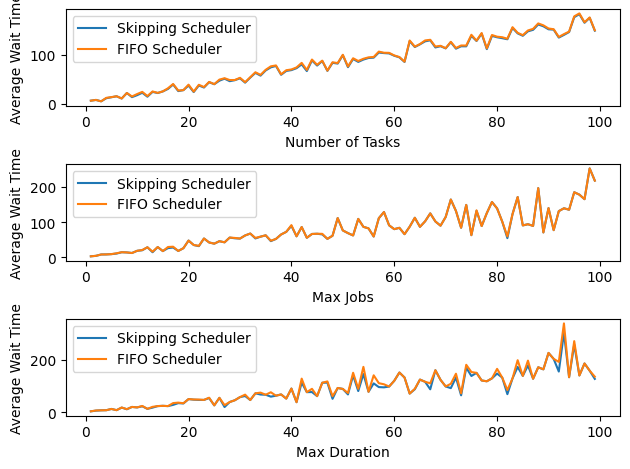

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3)

# Initialize lists to store wait times
wait_times_tasks = []
fifo_wait_times_tasks = []
wait_times_jobs = []
fifo_wait_times_jobs = []
wait_times_duration = []
fifo_wait_times_duration = []

num_samples = 100

for num_tasks in range(1, num_samples):
    queue, fifo = Queue(), Queue()
    tasks = create_tasks(num_tasks, 5, 5)  # use fixed values for max_jobs and max_duration

    # Run the scheduler
    wait_time,  fifo_wait_time = run_schedulers(tasks, queue, fifo)

    # Store average wait times
    wait_times_tasks.append(wait_time)
    fifo_wait_times_tasks.append(fifo_wait_time)

for max_jobs in range(1, num_samples):
    queue, fifo = Queue(), Queue()
    tasks = create_tasks(5, max_jobs, 5)  # use fixed values for num_tasks and max_duration

    # Run the scheduler
    wait_time,  fifo_wait_time = run_schedulers(tasks, queue, fifo)

    # Store average wait times
    wait_times_jobs.append(wait_time)
    fifo_wait_times_jobs.append(fifo_wait_time)

for max_duration in range(1, num_samples):
    queue, fifo = Queue(), Queue()
    tasks = create_tasks(5, 5, max_duration)  # use fixed values for num_tasks and max_jobs

    # Run the scheduler
    wait_time,  fifo_wait_time = run_schedulers(tasks, queue, fifo)

    # Store average wait times
    wait_times_duration.append(wait_time)
    fifo_wait_times_duration.append(fifo_wait_time)

# Plot wait times against number of tasks
axs[0].plot(range(1, num_samples), wait_times_tasks, label='Skipping Scheduler')
axs[0].plot(range(1, num_samples), fifo_wait_times_tasks, label='FIFO Scheduler')
axs[0].set_xlabel('Number of Tasks')
axs[0].set_ylabel('Average Wait Time')

# Plot wait times against max_jobs
axs[1].plot(range(1, num_samples), wait_times_jobs, label='Skipping Scheduler')
axs[1].plot(range(1, num_samples), fifo_wait_times_jobs, label='FIFO Scheduler')
axs[1].set_xlabel('Max Jobs')
axs[1].set_ylabel('Average Wait Time')

# Plot wait times against max_duration
axs[2].plot(range(1, num_samples), wait_times_duration, label='Skipping Scheduler')
axs[2].plot(range(1, num_samples), fifo_wait_times_duration, label='FIFO Scheduler')
axs[2].set_xlabel('Max Duration')
axs[2].set_ylabel('Average Wait Time')

for ax in axs:
    ax.legend()

plt.tight_layout()
plt.show()